In [2]:
# 1. INSTALACIÓN DE MÓDULOS (Limpia y rápida)
%pip install -q amplpy ipywidgets
!python -m amplpy.modules install cplex


# Reemplaza "TU-UUID-AQUI" por el código real de tu licencia
!python -m amplpy.modules activate "6ea90605-659e-464d-a07c-9fc44844e714"


import pandas as pd
from amplpy import AMPL, modules
from IPython.display import display, HTML
import ipywidgets as widgets

# 2. INICIALIZACIÓN Y CONFIGURACIÓN DE PANDAS
modules.load()
ampl = AMPL()
pd.options.display.float_format = '{:,.2f}'.format # Números reales con comas
pd.set_option('display.max_rows', None)

# 3. DEFINICIÓN DEL MODELO AMPL (.mod)
ampl.eval(r"""
# -------------------------------------------------
# CONJUNTOS
# -------------------------------------------------
set N := 1..52;

param Lmax;
param Emax;
param Lsup;
param R;
param C_es;
param C_m;
param alpha;
param dis{N, N} default 0;
param X{N};
param Y{N};
param F{N, N} default 0;

set L := 1..Lsup;
set A := {(i,j) in N cross N: dis[i,j] > 0};

param Geo_Dist{o in N, j in N} =
    ( (X[o] - X[j])^2 + (Y[o] - Y[j])^2 )^0.5 * 111.12 * 1000;

set P_all := {(o,j) in N cross N: F[o,j] > 0};
set P := {(o,j) in P_all: Geo_Dist[o,j] >= 2000};
set S{i in N} := {j in N: Geo_Dist[i,j] <= R};

var z{(o,j) in P, l in L} binary;
var zo{N, L} binary;
var zd{N, L} binary;
var x{A, L} binary;
var g{N, L} binary;

maximize Flujo_Capturado:
    sum{(o,j) in P, l in L} F[o,j] * z[o,j,l];

subject to R1_Un_Origen {l in L}:
    sum{i in N} zo[i,l] <= 1;

subject to R2_Mismo_Destino {l in L}:
    sum{i in N} zo[i,l] = sum{i in N} zd[i,l];

subject to R3_No_Mismo_Nodo {i in N, l in L}:
    zo[i,l] + zd[i,l] <= 1;

subject to R4_Maximo_Lineas:
    sum{l in L, i in N} zo[i,l] <= Lsup;

subject to R5_Conservacion_Flujo {i in N, l in L}:
    sum{(i,j) in A} x[i,j,l] - sum{(j,i) in A} x[j,i,l] = zo[i,l] - zd[i,l];

subject to R6_Un_Arco_Saliendo {i in N, l in L}:
    sum{(i,j) in A} x[i,j,l] <= 1;

subject to R7_Un_Arco_Entrando {i in N, l in L}:
    sum{(j,i) in A} x[j,i,l] <= 1;

subject to R8_Cobertura_Origen {(o,j) in P, l in L}:
    z[o,j,l] <= sum{i in S[o]} g[i,l];

subject to R9_Cobertura_Destino {(o,j) in P, l in L}:
    z[o,j,l] <= sum{i in S[j]} g[i,l];

subject to R10_Max_Largo_Linea {l in L}:
    sum{(i,j) in A} x[i,j,l] <= Lmax;

subject to R11_Origen_Estacion {i in N, l in L}:
    zo[i,l] <= g[i,l];

subject to R12_Destino_Estacion {i in N, l in L}:
    zd[i,l] <= g[i,l];

subject to R13_Enlace_Ruta_Estacion {i in N, l in L}:
    g[i,l] <= zo[i,l] + zd[i,l] + sum{(j,i) in A} x[j,i,l];

subject to R14_Activar_Arcos {(i,j) in A, l in L}:
    x[i,j,l] <= sum{k in N} zo[k,l];

subject to R15_Activar_Estaciones {i in N, l in L}:
    g[i,l] <= sum{k in N} zo[k,l];

subject to R16_Max_Estaciones {l in L}:
    sum{i in N} g[i,l] <= Emax;

subject to R17_Flujo_Una_Linea {(o,j) in P}:
    sum{l in L} z[o,j,l] <= 1;

subject to R18_Corte_Simetria {l in 1..(Lsup-1)}:
    sum{i in N} zo[i,l] >= sum{i in N} zo[i,l+1];
""")

# 4. CARGA DE DATOS (.dat)
with open('Tarea_2.dat', 'w') as f:
    f.write(r"""
param Lmax := 8;
param Emax := 4;
param Lsup := 3;
param R    := 300;
param C_es := 100000;
param C_m  := 100;
param alpha := 0.5;

param X :=
1 -71.602470649287
2 -71.6042813940875
3 -71.6056322565603
4 -71.6046828177262
5 -71.6068717128707
6 -71.6072382333447
7 -71.6136340558885
8 -71.6130532007688
9 -71.6065887386695
10 -71.6098303254321
11 -71.6128524165151
12 -71.6128469582578
13 -71.6163843381124
14 -71.6162482688575
15 -71.6198000301402
16 -71.6195567089209
17 -71.6098814575589
18 -71.6098393239423
19 -71.6158711739537
20 -71.6159090256683
21 -71.6188065387062
22 -71.618716439402
23 -71.6214438947406
24 -71.6219517371903
25 -71.6227795049413
26 -71.6246144534279
27 -71.6230310411541
28 -71.6245301595419
29 -71.6256765779457
30 -71.6279563888405
31 -71.6288992081975
32 -71.6301327616809
33 -71.6288082520995
34 -71.6293644494466
35 -71.6303298770551
36 -71.6293696517703
37 -71.6335061322932
38 -71.609794993762
39 -71.6160841077434
40 -71.6131510946342
41 -71.615986022693
42 -71.6191418927666
43 -71.6070627766995
44 -71.6101310936227
45 -71.6066879878186
46 -71.6262571230426
47 -71.6051208195805
48 -71.6028152555594
49 -71.605736991199
50 -71.6145290886345
51 -71.617815514072
52 -71.6327929333333
;

param Y :=
1 -33.0512132886041
2 -33.0467717374038
3 -33.0441223689984
4 -33.0458619276717
5 -33.0475571689871
6 -33.0447636851598
7 -33.0476016642232
8 -33.044983141213
9 -33.0502968912939
10 -33.0494318249532
11 -33.0487568678532
12 -33.0498395336937
13 -33.049011957109
14 -33.0479129222123
15 -33.0479315247505
16 -33.0467951983117
17 -33.0474454510682
18 -33.0447929348885
19 -33.0448450043198
20 -33.0435460822961
21 -33.0447549309716
22 -33.043462220288
23 -33.042960748551
24 -33.044101062636
25 -33.0452420851514
26 -33.0432120008561
27 -33.0421893136639
28 -33.040890065721
29 -33.0399148822466
30 -33.0382375748355
31 -33.0358826424851
32 -33.0360385856625
33 -33.0387394391261
34 -33.0344141980252
35 -33.0342174382684
36 -33.0278072041545
37 -33.0221495117803
38 -33.046170191763
39 -33.0469855295571
40 -33.0461523827041
41 -33.0459955585567
42 -33.045934448669
43 -33.0462331270709
44 -33.0502241551946
45 -33.05096980464
46 -33.0405384200254
47 -33.0423877338835
48 -33.0499021289139
49 -33.0510702744186
50 -33.0494273752895
51 -33.0468471060365
52 -33.0331538271321
;

param dis :=
  29 46 94.66954278997486
  7 17 417.34986783688595
  5 9 306.0574978237237
  4 43 267.658388891163
  12 44 304.7982186209965
  44 45 391.46695473100004
  10 44 94.17370608217107
  9 45 75.58306639353374
  16 25 397.532862710506
  33 46 346.8758439080908
  26 46 348.68312063855046
  25 26 304.0767521469054
  19 21 326.3312603519538
  41 42 350.74602192719294
  14 16 388.04724260973035
  13 14 123.05718719544936
  15 16 129.13095424146167
  16 42 106.1741214365806
  21 42 136.262498569891
  21 22 143.99449071535716
  21 24 356.9671379129675
  23 24 138.70963950283175
  24 25 156.64104534622706
  23 27 196.09281646446325
  26 27 209.4570299191371
  27 28 220.43813967030337
  28 29 167.2442001456952
  29 30 314.5088207036472
  30 33 109.86496710042904
  34 35 109.48364767436236
  31 34 171.16731441395868
  31 32 138.16343142717722
  35 36 720.2524965602713
  36 37 778.7915109873059
  32 33 334.26504879529807
  32 35 203.5478283480583
  30 31 281.8730187451581
  13 15 398.08708765534453
  1 9 468.79530473944016
  9 10 372.81090399623633
  10 11 344.08827173507535
  11 12 120.30735707506734
  10 17 220.79898287688042
  17 38 142.03215146808444
  5 17 334.6731482078621
  38 43 303.68449377996546
  5 43 148.6514993408729
  2 5 300.7773156468296
  2 4 110.5012661686624
  3 4 220.2166974988218
  3 6 192.1588316064147
  6 43 164.4442562155949
  6 18 289.05146133475006
  18 38 153.12004020314603
  8 18 357.7508823122401
  8 40 130.38069403871975
  7 40 169.7507939816067
  7 39 280.7265098408199
  14 39 104.65392320034768
  11 14 388.8256536488993
  38 40 372.93517948591534
  40 41 315.4988366290392
  39 41 110.54419881387832
  8 19 313.5091770526046
  19 41 128.48496131283068
  18 20 688.5488768689578
  35 52 298.12307076903954
  39 51 193.00776142897672
  16 51 193.56752883433904
  12 50 192.44743016319322
  13 50 211.26021742328894
  45 49 106.2628392225026
  1 49 363.3036502066874
  1 48 150.6441842810447
  2 48 384.11072690846123
  2 47 496.00017437477084
  19 20 144.39748671457565
  20 22 312.0989660973835
  22 23 308.15494447450584
;

param F :=
[2,5] 1095
[2,7] 365
[2,15] 365
[2,16] 365
[2,20] 365
[2,39] 365
[3,5] 2190
[3,7] 1095
[3,10] 365
[3,17] 730
[3,18] 365
[3,23] 365
[3,25] 365
[3,38] 365
[3,51] 365
[4,5] 1095
[4,15] 1095
[5,1] 365
[5,2] 730
[5,5] 1460
[5,6] 365
[5,7] 365
[5,9] 730
[5,10] 1460
[5,15] 730
[5,25] 365
[5,37] 365
[5,39] 730
[5,41] 365
[5,42] 365
[5,43] 365
[5,50] 730
[5,52] 365
[6,1] 365
[6,2] 730
[6,3] 1095
[6,4] 1460
[6,7] 730
[6,8] 365
[6,15] 365
[6,16] 365
[6,23] 365
[6,24] 365
[6,31] 365
[6,39] 365
[6,41] 365
[6,42] 2190
[6,43] 365
[6,45] 730
[6,50] 730
[7,4] 730
[7,5] 365
[8,1] 730
[8,2] 1095
[8,4] 365
[8,5] 1095
[8,6] 365
[8,9] 730
[8,10] 730
[8,14] 365
[8,17] 730
[8,19] 1095
[8,20] 365
[8,23] 365
[8,24] 365
[8,30] 365
[8,32] 365
[8,38] 730
[8,39] 1825
[8,43] 730
[8,44] 365
[8,45] 365
[9,5] 365
[9,9] 365
[9,16] 365
[9,38] 365
[10,4] 1095
[10,5] 730
[10,7] 730
[10,8] 365
[10,52] 365
[11,2] 365
[11,4] 1460
[11,5] 730
[11,18] 365
[11,19] 1460
[11,20] 365
[11,32] 365
[11,34] 365
[11,39] 365
[11,42] 730
[11,49] 365
[11,50] 365
[12,21] 365
[13,5] 365
[13,10] 365
[13,23] 730
[15,15] 365
[15,38] 1095
[15,42] 365
[15,48] 365
[15,50] 365
[16,4] 365
[16,5] 1095
[16,18] 365
[16,20] 365
[16,21] 1095
[16,23] 730
[16,24] 730
[16,25] 365
[16,27] 365
[16,29] 365
[16,38] 730
[16,40] 365
[16,45] 365
[16,50] 365
[16,52] 365
[17,1] 365
[17,5] 1460
[17,8] 365
[17,15] 365
[17,19] 365
[17,25] 365
[17,29] 730
[17,38] 365
[17,41] 365
[17,42] 365
[18,2] 730
[18,7] 730
[18,21] 365
[18,25] 365
[18,52] 365
[19,10] 365
[19,15] 365
[19,25] 365
[19,39] 365
[19,45] 365
[19,49] 365
[20,6] 365
[20,7] 730
[20,10] 1460
[20,15] 365
[20,16] 730
[20,20] 1095
[20,21] 1095
[20,23] 730
[20,24] 730
[20,27] 365
[20,38] 365
[20,39] 1095
[20,41] 1460
[20,45] 730
[20,50] 730
[21,7] 730
[21,10] 730
[21,19] 1460
[21,21] 365
[21,23] 365
[21,26] 365
[21,27] 365
[21,31] 730
[21,38] 730
[21,49] 365
[22,15] 1460
[22,17] 365
[22,19] 730
[22,20] 730
[22,23] 365
[22,24] 730
[22,25] 365
[22,27] 730
[22,50] 365
[24,14] 365
[24,15] 730
[24,16] 365
[24,19] 365
[24,20] 365
[24,24] 365
[24,25] 1460
[24,26] 365
[24,27] 1095
[24,29] 730
[24,38] 365
[24,41] 365
[25,1] 365
[25,4] 365
[25,15] 365
[25,18] 365
[25,19] 1460
[25,21] 730
[25,23] 730
[25,25] 365
[25,32] 730
[26,2] 365
[26,4] 365
[26,15] 1095
[26,18] 365
[26,20] 1095
[26,23] 1095
[26,24] 730
[26,34] 365
[26,41] 1095
[26,45] 365
[26,50] 365
[27,4] 730
[27,23] 1095
[27,24] 730
[27,25] 365
[27,32] 365
[27,41] 730
[27,50] 365
[28,1] 365
[28,19] 730
[28,21] 730
[28,23] 365
[28,25] 2190
[28,29] 365
[28,32] 730
[28,38] 365
[28,45] 1095
[28,50] 365
[30,4] 365
[30,23] 1095
[30,25] 365
[30,31] 365
[30,32] 365
[30,44] 365
[30,45] 730
[31,31] 365
[31,45] 365
[31,50] 365
[32,4] 365
[32,20] 730
[32,21] 365
[32,25] 365
[32,30] 365
[32,50] 730
[33,4] 730
[33,7] 365
[33,23] 365
[33,24] 730
[33,25] 365
[33,26] 730
[33,27] 1095
[33,29] 365
[33,37] 365
[33,43] 365
[33,45] 365
[33,48] 365
[33,50] 365
[35,10] 365
[35,25] 365
[38,16] 365
[39,4] 730
[39,5] 365
[39,6] 365
[39,7] 365
[39,15] 365
[39,19] 365
[39,20] 365
[39,25] 365
[39,40] 730
[39,41] 365
[39,43] 365
[39,50] 1460
[40,2] 365
[40,4] 365
[40,5] 365
[40,6] 730
[40,7] 1460
[40,10] 365
[40,18] 365
[40,19] 730
[40,32] 365
[40,40] 1095
[41,5] 365
[41,38] 365
[41,39] 1825
[41,43] 730
[41,48] 365
[42,4] 730
[42,19] 1460
[42,23] 2555
[42,26] 365
[42,29] 365
[42,31] 730
[42,38] 365
[42,40] 365
[43,4] 1460
[43,6] 730
[43,15] 730
[43,16] 365
[43,24] 365
[43,25] 365
[43,37] 365
[43,39] 730
[44,5] 730
[44,6] 365
[44,10] 365
[44,14] 365
[44,16] 365
[44,19] 365
[44,23] 365
[44,27] 365
[44,39] 365
[44,40] 730
[44,42] 365
[44,48] 365
[45,7] 365
[45,29] 365
[46,1] 730
[46,4] 365
[46,5] 365
[46,15] 730
[46,16] 365
[46,19] 365
[46,23] 730
[46,25] 1825
[46,26] 1095
[46,27] 730
[46,29] 1095
[46,30] 365
[46,31] 730
[46,32] 1095
[46,38] 1095
[46,39] 365
[46,48] 365
[48,2] 730
[48,43] 365
[49,14] 365
[49,32] 365
[49,40] 365
[49,43] 365
[49,45] 365
[50,18] 365
[51,3] 365
[51,4] 365
[51,10] 365
[51,15] 1095
[51,20] 365
[51,23] 730
[51,27] 365
[51,29] 365
[51,32] 365
[51,38] 730
[51,40] 365
[51,45] 365
[51,49] 1095
;
""")
ampl.read_data('Tarea_2.dat')

# 5. EJECUCIÓN CON CPLEX
ampl.set_option('solver', 'cplex')
ampl.set_option('cplex_options', 'timelimit 600')
print("\n--- Ejecutando Solve ---")
ampl.solve()

# 6. CÁLCULOS ADICIONALES (Costo)
flujo_capturado = ampl.get_value("sum{(o,j) in P, l in L} F[o,j] * z[o,j,l]")
costo_estaciones = ampl.get_value("C_es * (sum{i in N, l in L} g[i,l])")
costo_lineas = ampl.get_value("C_m * (sum{(i,j) in A, l in L} dis[i,j] * x[i,j,l])")
costo_final = costo_estaciones + costo_lineas

# 7. IMPLEMENTACIÓN VISUAL (Pestañas y Estilos)
def color_zeros(val):
    color = '#D3D3D3' if val == 0 else 'black'
    return f'color: {color}'

# Extraer variables binarias relevantes. Se asume que > 0.5 es "activo"
variables = ['z', 'g', 'x', 'zo', 'zd']
dfs_estilizados = {}

for var_name in variables:
    # Convertir a pandas y filtrar solo los valores activos para no saturar las tablas
    df_full = ampl.get_variable(var_name).get_values().to_pandas()
    df_filtro = df_full[df_full.iloc[:, 0] > 0.5]
    
    styler = df_filtro.style.applymap(color_zeros).format("{:,.0f}")
    dfs_estilizados[var_name] = styler

# Crear Tabs
tabs = []
titulos_tabs = ['Flujos Capturados (z)', 'Estaciones (g)', 'Arcos (x)', 'Orígenes (zo)', 'Destinos (zd)']

for i, var_name in enumerate(variables):
    out = widgets.Output()
    with out:
        display(HTML(f"<h3>Detalle de variable: {titulos_tabs[i]}</h3>"))
        if dfs_estilizados[var_name].data.empty:
            display(HTML("<p><i>No hay valores activos (1) para esta variable en la solución actual.</i></p>"))
        else:
            display(dfs_estilizados[var_name])
    tabs.append(out)

tab_control = widgets.Tab(children=tabs)
for i, titulo in enumerate(titulos_tabs):
    tab_control.set_title(i, titulo)

# Mostrar Encabezado e Interfaz
header_html = f"""
<div style="background-color: #1B4F72; padding: 25px; border-radius: 12px; color: white; font-family: sans-serif;">
    <h1 style="margin: 0;">Reporte de Diseño de Red - Flujo Máximo</h1>
    <hr style="border: 0.5px solid #5DADE2;">
    <p style="font-size: 20px;">Flujo Total Capturado: <span style="color: #F7DC6F;"><b>{flujo_capturado:,.0f} pasajeros</b></span></p>
    <p style="font-size: 14px;">Costo Total Estimado (Informativo): <b>${costo_final:,.2f}</b></p>
    <p style="font-size: 14px;">Solver utilizado: <b>CPLEX</b></p>
</div>
"""

display(HTML(header_html))
display(tab_control)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 41.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 102.7 MB/s eta 0:00:0000:01
$ /usr/bin/python3 -m pip install -i https://pypi.ampl.com ampl_module_base ampl_module_cplex
Looking in indexes: https://pypi.ampl.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 8.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 36.9 MB/s eta 0:00:00
Imported ampl_module_base.
Imported ampl_module_base.
Imported ampl_module_cplex.
$ amplkey activate --uuid 6ea90605-659e-464d-a07c-9fc44844e714
Wrote license to /usr/local/lib/python3.12/dist-packages/ampl_module_base/bin/ampl.lic
License 6ea90605-659e-464d-a07c-9fc44844e714 activated!
Please restart AMPL in order to start using the new license.

--- Ejecutando Solve ---
CPLEX 22.1.2:   lim:time = 600
CPLEX 22.1.2: optimal solution; objective 6570
363007 simplex iterations
11279 branching nodes


/tmp/ipykernel_1044/3847754295.py:696: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styler = df_filtro.style.applymap(color_zeros).format("{:,.0f}")


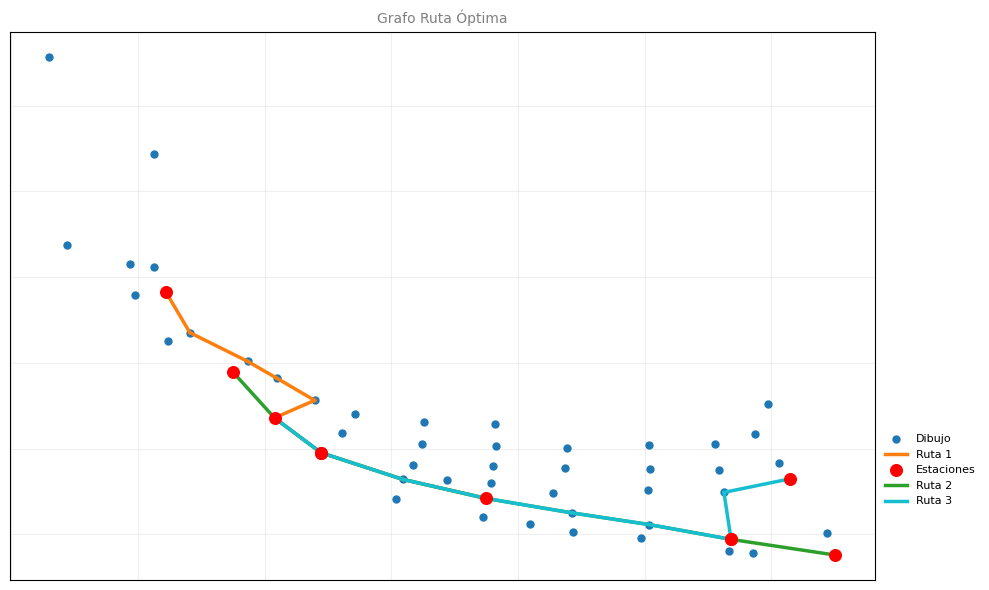

In [3]:
# 8. GRAFICAR LA RED ÓPTIMA (Matplotlib)
import matplotlib.pyplot as plt

# Extraer coordenadas y listas de AMPL
X_coords = ampl.get_parameter("X").get_values().to_dict()
Y_coords = ampl.get_parameter("Y").get_values().to_dict()
N_nodos = ampl.get_set("N").to_list()
L_lineas = ampl.get_set("L").to_list()

var_x = ampl.get_variable("x").get_values().to_dict()
var_g = ampl.get_variable("g").get_values().to_dict()

# Configurar el lienzo
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')
ax.grid(True, linestyle='-', alpha=0.5, color='#e0e0e0') # Cuadrícula gris clara

# 1. Graficar TODOS los nodos (Dibujo base)
nodos_x = [X_coords[i] for i in N_nodos]
nodos_y = [Y_coords[i] for i in N_nodos]
ax.scatter(nodos_x, nodos_y, c='#1f77b4', s=25, label='Dibujo', zorder=2) # Puntos azules

# Colores para las rutas (Naranja, Verde, Celeste)
colores_lineas = ['#ff7f0e', '#2ca02c', '#17becf']

# 2. Graficar Arcos (Rutas) y Estaciones
estaciones_graficadas = False # Para que "Estaciones" salga solo 1 vez en la leyenda

for idx, l in enumerate(L_lineas):
    # Buscar arcos activos para esta línea
    arcos_activos = [(i, j) for (i, j, linea) in var_x.keys() if linea == l and var_x.get((i, j, linea), 0) > 0.5]
    
    if arcos_activos:
        # Dibujar el primer arco con etiqueta para que aparezca en la leyenda
        primer_arco = arcos_activos[0]
        ax.plot([X_coords[primer_arco[0]], X_coords[primer_arco[1]]], 
                [Y_coords[primer_arco[0]], Y_coords[primer_arco[1]]], 
                color=colores_lineas[idx % len(colores_lineas)], linewidth=2.5, label=f'Ruta {int(l)}', zorder=3)
        
        # Dibujar el resto de los arcos de esta línea
        for i, j in arcos_activos[1:]:
            ax.plot([X_coords[i], X_coords[j]], 
                    [Y_coords[i], Y_coords[j]], 
                    color=colores_lineas[idx % len(colores_lineas)], linewidth=2.5, zorder=3)
    
    # Buscar estaciones activas para esta línea
    estaciones = [i for (i, linea) in var_g.keys() if linea == l and var_g.get((i, linea), 0) > 0.5]
    if estaciones:
        lbl = 'Estaciones' if not estaciones_graficadas else None
        ax.scatter([X_coords[i] for i in estaciones], [Y_coords[i] for i in estaciones], 
                   c='red', s=70, label=lbl, zorder=4)
        estaciones_graficadas = True

# 3. Configuraciones visuales finales (replicando el estilo de la imagen)
ax.set_title("Grafo Ruta Óptima", fontsize=10, color='gray')

# Crear leyenda y ubicarla a la derecha por fuera del gráfico
ax.legend(loc='center left', bbox_to_anchor=(1, 0.2), fontsize=8, frameon=False)

# Esconder los números y marcas de los ejes
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.tick_params(bottom=False, left=False)

# Ajustar márgenes y mostrar
plt.tight_layout()
plt.show()